# A Comprehension of Intelligent Document Processing

Intelligent Document Processing (IDP) is an advanced automation technology that transforms the way businesses handle documents. By leveraging artificial intelligence (AI), IDP systems can automatically read, understand, and process vast quantities of documents, extracting crucial data and feeding it into various business workflows. This technology is a significant leap from traditional Optical Character Recognition (OCR) as it not only digitizes text but also comprehends the context and structure of the information within documents.

At its core, IDP is designed to tackle the challenge of processing unstructured and semi-structured data, which make up a large portion of business documents such as invoices, contracts, emails, and forms. By automating the extraction and interpretation of this data, IDP significantly reduces the need for manual data entry, leading to increased efficiency, higher accuracy, and substantial cost savings.

<br><br>

---
<br><br>

### The Inner Workings of Intelligent Document Processing

The power of IDP lies in its sophisticated multi-step process that intelligently handles documents from ingestion to data delivery. This process typically involves several key stages:

**1. Document Ingestion:** The first step involves importing documents from various sources and in multiple formats, including scanned paper documents, PDFs, Word files, and images.

**2. Pre-processing:** To enhance the quality of the input, documents undergo a pre-processing stage. This includes techniques like noise reduction, image enhancement, and deskewing to improve the accuracy of subsequent data extraction.

**3. Document Classification:** Using machine learning algorithms, the IDP system automatically categorizes documents based on their layout and content. This allows the system to differentiate between an invoice, a purchase order, or a legal contract, for instance.

**4. Data Extraction:** This is the core function of IDP. Advanced AI technologies, including Natural Language Processing (NLP) and computer vision, are employed to identify and extract relevant data fields. For example, from an invoice, it can pull out the invoice number, date, vendor name, and line-item details.

**5. Data Validation:** The extracted data is then validated against predefined rules and existing databases to ensure accuracy and consistency. Any exceptions or discrepancies can be flagged for human review in a "human-in-the-loop" process, which also helps to train and improve the AI model over time.

**6. Integration:** Finally, the structured and validated data is seamlessly integrated into downstream business systems such as Enterprise Resource Planning (ERP), Customer Relationship Management (CRM), or other databases, making the information readily available for further processing and analysis.


From **finance departments** automating invoice processing and expense management to **healthcare organizations** streamlining patient record management and claims processing, IDP is proving to be a game-changer. Even  **human resources** can expedite resume screening and employee onboarding. As the technology continues to evolve, its applications are expected to expand even further, solidifying its role as a cornerstone of modern digital transformation.

In [10]:
!unzip '/content/archive (15).zip' -d resume_data

Archive:  /content/archive (15).zip
  inflating: resume_data/Resume/Resume.csv  
  inflating: resume_data/data/data/ACCOUNTANT/10554236.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/10674770.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/11163645.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/11759079.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/12065211.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/12202337.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/12338274.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/12442909.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/12780508.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/12802330.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/13072019.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/13130984.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/13294301.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/13491889.pdf  
  inflating: resume_data/data/data/ACCOUNTANT/13701259.pdf  
  in

# Our Approach

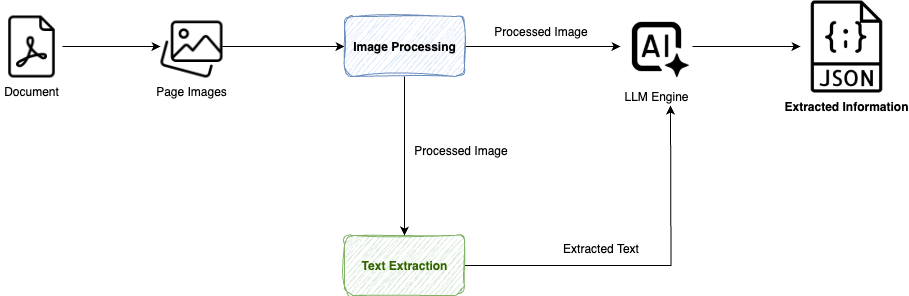

# SROIEv2: The Receipts Dataset

## Getting the data

Since these are single-paged images already, we don't need to convert them

## Understanding the data


The downloaded dataset contains two major folders:
1. **train**: This folder contains the training data.
2. **test**: This folder contains the test data.

Each of these folders contains the following subfolders:
1. **img**: This folder containing the images of the receipts.
2. **box**: This folder containing the bounding box information of the text in the images and the text inside the bounding boxes. The file is a text file with the same name as the image file but with a .txt extension. The format of the file is as follows:
    ```
    x1, y1, x2, y2, x3, y3, x4, y4, text
    ```
    where (x1, y1), (x2, y2), (x3, y3), and (x4, y4) are the coordinates of the bounding box and text is the text inside the bounding box.
3. **entities**: This folder contains the ground truth information of the entities in the receipts. The file is a text file with the same name as the image file but with a .txt extension. The file contains json data with the following format:
    ```json
    {
        "company": "COMPANY_NAME",
        "date": "DATE",
        "address": "ADDRESS",
        "total": "TOTAL",
    }
    ```

## Image Preprocesing: OpenCV

In [2]:
! pip install opencv-python matplotlib numpy

Let's take one image and play with it.

In [3]:
import pandas as pd

# Assuming Resume.csv is extracted to the 'Resume' folder
resume_csv_path = '/content/Resume/Resume.csv'
df_resume = pd.read_csv(resume_csv_path)

print('Resume Dataset Head:')
display(df_resume.head())

Resume Dataset Head:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def display_image(image, title="Image"):
    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

Let's check the information about the `df_resume` DataFrame.

In [8]:
print('Resume Categories and their counts:')
display(df_resume['Category'].value_counts())

Resume Categories and their counts:


,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


In [7]:
df_resume.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [11]:
import os
path="/content/resume_data"
one_image_path = os.path.join(path, 'data','data',
    'ENGINEERING',
    '10030015.pdf')

### Grayscale Conversion

**Why?** Color information is usually not necessary for reading the text on a receipt. Converting the image to grayscale simplifies it from three color channels (Red, Green, Blue) to a single channel (intensity/brightness). This reduces computational complexity and is a required first step for many subsequent operations like thresholding.

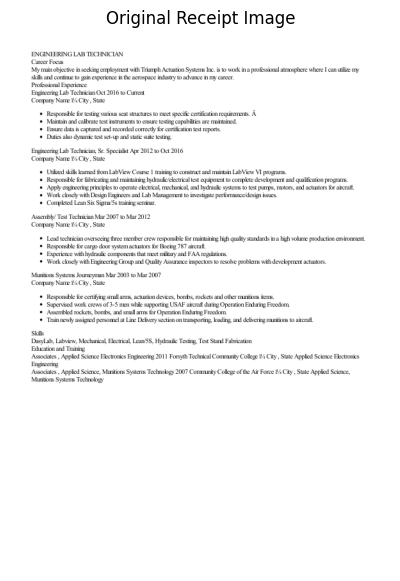

In [22]:
!pip install PyMuPDF

import fitz # PyMuPDF

pdf_document = fitz.open(one_image_path)
page = pdf_document.load_page(0) # Load the first page
pix = page.get_pixmap() # Render page to an image (pixmap)
img_np = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.h, pix.w, pix.n) # Convert to numpy array

# Convert RGB to BGR for OpenCV if pix.n is 3
if pix.n == 3:
    one_image = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
elif pix.n == 4: # RGBA to BGR
    one_image = cv2.cvtColor(img_np, cv2.COLOR_RGBA2BGR)
else: # Grayscale etc.
    one_image = img_np
pdf_document.close()

display_image(one_image, "Original Receipt Image")

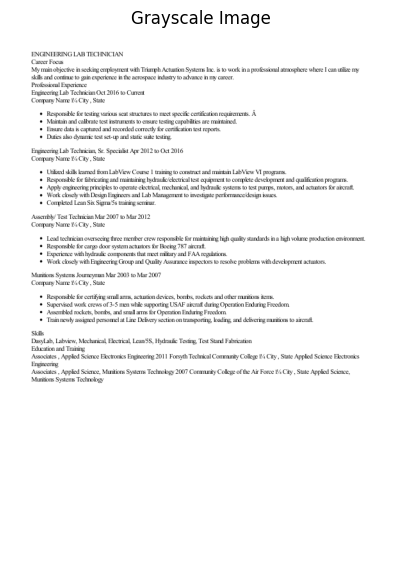

In [27]:
grayscale_image = convert_to_grayscale(one_image)
display_image(grayscale_image, "Grayscale Image")

### Noise (blur) Reduction
**Why?** Scanned images or photos often contain "noise" (random variations in brightness or color). This can look like small specks or graininess, which can confuse OCR algorithms. Applying a slight blur helps to smooth out this noise. A **Gaussian blur** is a common choice as it effectively averages out pixel values with a weighted average, preserving edges better than a simple blur.

In [28]:
def reduce_noise(gray_image):
  return cv2.GaussianBlur(gray_image, (5, 5), 0)

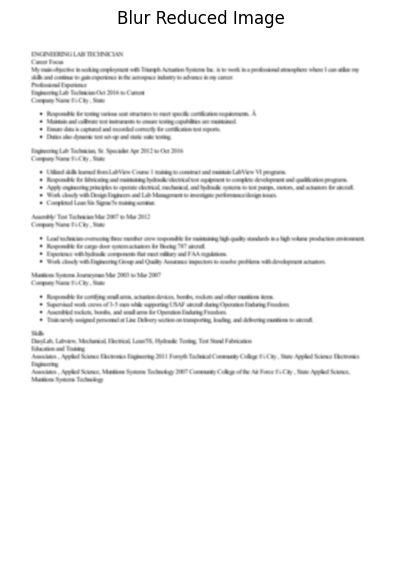

In [29]:
blur_reduced_image = reduce_noise(grayscale_image)
display_image(blur_reduced_image, "Blur Reduced Image")

### Binarization (Thresholding)

**Why?** This is one of the most critical steps. Binarization converts the grayscale image into a pure black-and-white image. The goal is to make the text **black** and the background **white**. However, receipts often have uneven lighting or shadows, so a simple (global) threshold won't work well. We use **adaptive thresholding**, which calculates a different threshold for smaller regions of the image, making it robust to lighting changes.

`cv2.adaptiveThreshold()`:

  * `cv2.ADAPTIVE_THRESH_GAUSSIAN_C`: Calculates the threshold for a pixel based on a weighted sum of neighborhood values.
  * `cv2.THRESH_BINARY_INV`: Inverts the result. We want the text to be white pixels (value 255) and the background black (value 0) for the next step (skew correction), which often works by finding white pixel contours.
  * `11`: The size of the neighborhood area (block size).
  * `4`: A constant subtracted from the mean. It's a fine-tuning parameter.

In [31]:
def binarize_image(blur_reduced_image):
  return cv2.adaptiveThreshold(
    blur_reduced_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, # Invert the colors (text becomes white because of matplotlib)
    11, # Block size
    4  # Constant C
  )

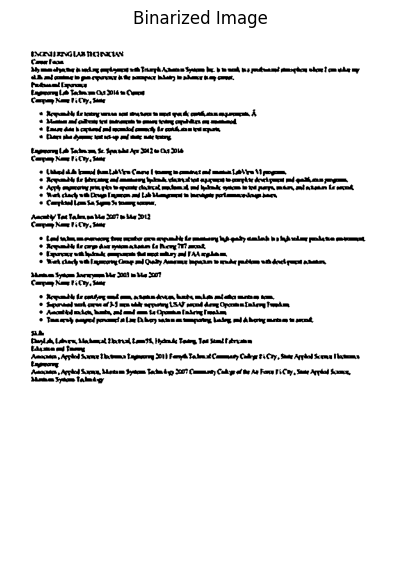

In [32]:
binarized_image = binarize_image(blur_reduced_image)
display_image(binarized_image, "Binarized Image")

### Skew Correction

**Why?** Receipts are often scanned or photographed at a slight angle. This skew can significantly reduce the accuracy of OCR. We need to detect this angle and rotate the image to make the text perfectly horizontal.

A common technique is to find the angle of the minimum-area bounding box that encloses all the text (the white pixels in our binarized image) and then rotate the original image by that angle.

In [33]:
def deskew_image(image):
    """
    Corrects the skew of an image by finding the minimum area rectangle
    of the text block and rotating accordingly.
    """
    # Find all non-zero (white) pixels
    coords = cv2.findNonZero(image)

    # Get the minimum area bounding rectangle
    # It returns (center(x,y), (width, height), angle of rotation)
    rect = cv2.minAreaRect(coords)
    angle = rect[-1] - 90

    # The `cv2.minAreaRect` angle has a specific range.
    # We need to adjust it for our rotation.
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = angle

    # Get the rotation matrix and rotate the image
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h),
                             flags=cv2.INTER_CUBIC,
                             borderMode=cv2.BORDER_REPLICATE)
    # print(f"Detected skew angle: {angle:.2f} degrees")

    # Now, rotate the original grayscale image by the same angle
    (h, w) = rotated.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    deskewed_gray = cv2.warpAffine(rotated, M, (w, h),
                                  flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REPLICATE)

    return deskewed_gray

In [34]:
deskewed_image = deskew_image(binarized_image)

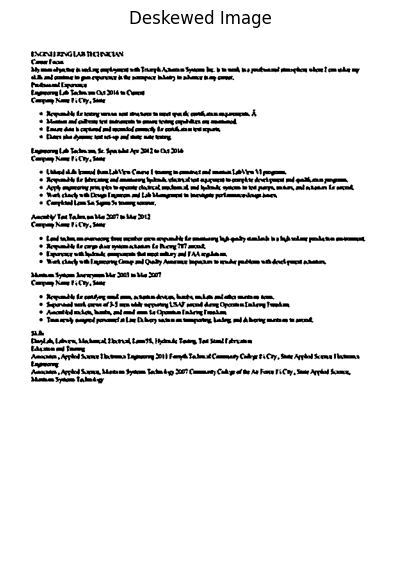

In [35]:
display_image(deskewed_image, "Deskewed Image")

Let's run the above code for all images

In [39]:
os.path.join(path, 'ENGINEERING', 'train', 'img', '10030015.pdf')

'/content/resume_data/ENGINEERING/train/img/10030015.pdf'

In [40]:
def process_one_image(image):
  image = convert_to_grayscale(image)
  # print("Converted image to grayscale..")
  image = reduce_noise(image)
  # print("Reduced noise in the image..")
  image = binarize_image(image)
  # print("Binarized the image..")
  image = deskew_image(image)
  # print("Corrected image orientation..")
  return image

In [46]:
import time
from tqdm.auto import tqdm
import fitz  # PyMuPDF

output_folder_path = "/content/processed_images"
start_time = time.time()

# Create output folder if not exists
os.makedirs(output_folder_path, exist_ok=True)
print(f"Output folder ready: {output_folder_path}")

# Define directory containing PDFs
pdf_directory = os.path.join(path, 'data', 'data', 'ENGINEERING')

# Check directory
if not os.path.isdir(pdf_directory):
    raise FileNotFoundError(f"Directory not found: {pdf_directory}")

# List ALL PDF files
pdf_files = [f for f in os.listdir(pdf_directory) if f.lower().endswith('.pdf')]

print(f"Total PDFs found: {len(pdf_files)}")

# Process ALL PDFs (removed [:20])
for pdf_name in tqdm(pdf_files):
    # print(f"Processing PDF: {pdf_name}")

    pdf_file_path = os.path.join(pdf_directory, pdf_name)

    try:
        pdf_document = fitz.open(pdf_file_path)

        # OPTIONAL: process ALL pages instead of only first page
        for page_num in range(len(pdf_document)):
            page = pdf_document.load_page(page_num)
            pix = page.get_pixmap(dpi=300)

            img_np = np.frombuffer(
                pix.samples, dtype=np.uint8
            ).reshape(pix.h, pix.w, pix.n)

            # Convert to OpenCV format
            if pix.n == 3:
                current_image = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
            elif pix.n == 4:
                current_image = cv2.cvtColor(img_np, cv2.COLOR_RGBA2BGR)
            else:
                current_image = img_np

            processed_image = process_one_image(current_image)

            # Save page-wise output
            output_image_name = pdf_name.replace(
                ".pdf", f"_page_{page_num}.jpg"
            )
            output_path = os.path.join(output_folder_path, output_image_name)

            cv2.imwrite(output_path, processed_image)

        pdf_document.close()

    except Exception as e:
        print(f"❌ Error processing {pdf_name}: {e}")

print("Processing images is completed.")
print(f"Total time taken: {time.time() - start_time} seconds")


Output folder ready: /content/processed_images
Total PDFs found: 118


  0%|          | 0/118 [00:00<?, ?it/s]

Processing images is completed.
Total time taken: 385.27165818214417 seconds


## Text Extraction: Tesseract

Tesseract OCR is a powerful and widely-used open-source optical character recognition (OCR) engine. In simple terms, it's a software that can "read" text from images and convert it into machine-readable text. This means you can take a picture of a document, a sign, or any other object containing text, and Tesseract can extract that text so you can edit, search, or analyze it.

### A Brief History and Development

Originally developed by Hewlett-Packard in the 1980s, Tesseract was later open-sourced in 2005 and has been sponsored by Google since 2006. This has led to significant improvements and made it one of the most accurate and versatile free OCR engines available. The latest versions of Tesseract utilize long short-term memory (LSTM), a type of recurrent neural network (RNN), which has greatly enhanced its ability to recognize text with high accuracy.



### Core Functionalities and Capabilities

Tesseract boasts a rich set of features that make it a flexible tool for various applications:

  * **Extensive Language Support:** Tesseract can recognize over 100 languages, making it a truly global OCR solution. It also supports multiple scripts and can even be trained to recognize new languages.
  * **Multiple Output Formats:** It can output the recognized text in various formats, including plain text, HTML, PDF, and TSV (tab-separated values). This allows for easy integration with other software and workflows.
  * **Page Segmentation Modes:** Tesseract offers different page segmentation modes, which help in correctly identifying the layout of a document, including columns, paragraphs, and blocks of text.
  * **Character Recognition and Confidence:** Not only does it recognize characters, but it can also provide a confidence score for each recognized character, word, or line. This is useful for assessing the accuracy of the OCR process.
  * **Command-Line and API Access:** Tesseract can be used as a command-line tool for quick and simple OCR tasks. For more complex integrations, it provides an API that allows developers to incorporate its OCR capabilities into their own applications. Popular wrappers like Pytesseract make it easy to use Tesseract with programming languages like Python.


### Installation
`pip install pytesseract pillow`


### How to Use Tesseract

For developers, integrating Tesseract into an application is straightforward using its API. Here is a simple example using the `pytesseract` wrapper in Python:

```python

from PIL import Image
import pytesseract


text = pytesseract.image_to_string(Image.open(filename))

print(text)
```



### Common Use Cases and Applications

The ability to extract text from images opens up a vast range of applications across various industries:

  * **Document Digitization:** Converting scanned documents, books, and historical archives into searchable digital text.
  * **Data Entry Automation:** Automating the process of entering data from invoices, receipts, and forms.
  * **Accessibility:** Assisting visually impaired individuals by converting printed text into speech.
  * **License Plate Recognition:** In law enforcement and traffic management systems.
  * **Social Media Monitoring:** Analyzing text within images shared on social media platforms.
  * **Translation:** Extracting text from an image and then using a translation service to translate it.

While Tesseract is a powerful tool, the accuracy of its output heavily depends on the quality of the input image. For best results, images should be clear, well-lit, and have a high resolution. Pre-processing steps like resizing, noise reduction, and converting to grayscale can significantly improve OCR accuracy.

In [47]:
! pip install pytesseract pillow

In [53]:
from PIL import Image
import pytesseract

print(pytesseract.image_to_string(Image.open('/content/processed_images/10030015_page_0.jpg')))

ENGINEERING LAB TECHNICIAN

Career Focus

My main objective in seeking employment with Triumph Actuation Systems Inc. is to work in a professional atmosphere where I can utilize my
skills and continue to gain experience in the aerospace industry to advance in my career.

Professional Experience

Engineering Lab Technician Oct 2016 to Current

Company Name i'/ City , State

° Responsible for testing various seat structures to meet specific certification requirements. A
e Maintain and calibrate test instruments to ensure testing capabilities are maintained.

e Ensure data is captured and recorded correctly for certification test reports.

© Duties also dynamic test set-up and static suite testing,

Engineering Lab Technician, Sr. Specialist Apr 2012 to Oct 2016
Company Name i'/ City , State

© Utilized skills leamed ftom Lab View Course 1 training to construct and maintain LabView VI programs.
© Responsible for fabricating and maintaining hydraulic/electrical test equipment to complete d

In [54]:
from PIL import Image
import pytesseract
import time

input_folder_path = "/content/processed_images"
output_folder_path = "/content/tesseract_output"
start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(input_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:20], 1):
  print(f"Processing image {i}/{total_images}: {image_name}")
  image_path = os.path.join(input_folder_path, image_name)
  print("Extracting text from image..")
  text = pytesseract.image_to_string(Image.open(image_path))
  output_path = os.path.join(output_folder_path, image_name.replace(".jpg", ".txt"))
  with open(output_path, "w") as f:
    f.write(text)

  print(f"Saved extracted text to {output_path}")
  print("-"*50)

print("Text Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total images in folder: 227
Processing image 1/227: 16803215_page_0.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/16803215_page_0.txt
--------------------------------------------------
Processing image 2/227: 55953734_page_1.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/55953734_page_1.txt
--------------------------------------------------
Processing image 3/227: 62071407_page_0.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/62071407_page_0.txt
--------------------------------------------------
Processing image 4/227: 12748557_page_0.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/12748557_page_0.txt
--------------------------------------------------
Processing image 5/227: 19124258_page_0.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/19124258_page_0.txt
--------------------------------------------------
Pr

## Information Extraction

In [55]:
prompt = """
Extract the information from the given image.
Information to be extracted: company, date, address, total.
The image has been converted to grayscale, noise reduced, binarized, and deskewed using opencv.
Always give your response in the following format:
{
    "company": "COMPANY_NAME",
    "date": "DATE",
    "address": "ADDRESS",
    "total": "TOTAL",
}
Also, the text has been extracted from the image using tesseract.
Use the extracted text as support for extracting information.
If you believe the text extraction is incorrect somewhere, you may correct it yourself and provide corrected information.
Respond with the extracted information only in the specified format.
Here is the text:


"""

Can we improve the prompt using the [Unified Framework For An Effective Prompt](https://www.geeksforgeeks.org/data-science/a-unified-framework-for-an-effective-prompt/)?

In [56]:
from google import genai
from google.colab import userdata # colab only code
from PIL import Image
import json
import time

In [57]:
genai_client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

In [58]:
image_folder_path = "/content/processed_images"
text_folder_path = "/content/tesseract_output"
output_folder_path = "/content/json_output"

start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(image_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:20], 1):

  print(f"Processing image {i}/{total_images}: {image_name}")

  image_path = os.path.join(input_folder_path, image_name)

  print(f"Loading image: {image_path}")
  with open(image_path, "rb") as f:
    image = Image.open(image_path)
    # print(image)


  text_path = os.path.join(text_folder_path, image_name.replace(".jpg", ".txt"))

  print(f"Loading extracted text: {text_path}")
  with open(text_path, "r") as f:
    text = f.read()

  print("Extracting information from image and text..")

  prompt = prompt + text



  contents = [
        image,
        {
            "text": prompt
        }
    ]
  response = genai_client.models.generate_content(model='gemini-2.5-flash', contents=contents)

  # Access the usage_metadata attribute

  usage_metadata = response.usage_metadata

  # Print the different token counts
  print(f"Input Token Count: {usage_metadata.prompt_token_count}")
  print(f"Thoughts Token Count: {response.usage_metadata.thoughts_token_count}")
  print(f"Output Token Count: {usage_metadata.candidates_token_count}")
  print(f"Total Token Count: {usage_metadata.total_token_count}")

  extracted_information = json.loads(response.text.replace('```json', '').replace('```', ''))

  output_path = os.path.join(output_folder_path, image_name.replace(".jpg", ".json"))
  with open(output_path, "w") as f:
    json.dump(extracted_information, f, indent=4)

  print(f"Saved extracted information to {output_path}")
  print("-"*50)
  time.sleep(60)

print("Information Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total images in folder: 227
Processing image 1/227: 16803215_page_0.jpg
Loading image: /content/processed_images/16803215_page_0.jpg
Loading extracted text: /content/tesseract_output/16803215_page_0.txt
Extracting information from image and text..
Input Token Count: 1271
Thoughts Token Count: 1154
Output Token Count: 58
Total Token Count: 2483
Saved extracted information to /content/json_output/16803215_page_0.json
--------------------------------------------------
Processing image 2/227: 55953734_page_1.jpg
Loading image: /content/processed_images/55953734_page_1.jpg
Loading extracted text: /content/tesseract_output/55953734_page_1.txt
Extracting information from image and text..
Input Token Count: 1496
Thoughts Token Count: 3481
Output Token Count: 56
Total Token Count: 5033
Saved extracted information to /content/json_output/55953734_page_1.json
--------------------------------------------------
Processing image 3/227: 62071407_page_0.jpg
Loading image: /content/processed_images/620

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

# Can you play with a Resume Dataset?

https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset